In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE #Synthetic  Minority Oversampling Technique- here used to generate sythentic fraud data
import warnings
warnings.filterwarnings('ignore')

# Step 1: Load the dataset
data = pd.read_csv('/content/creditcard.csv')
# Step 2: Explore the data
print("First few rows of the dataset:")
print(data.head())
print("\nMissing values in each column:")
print(data.isnull().sum())
print("\nClass distribution (0=Non-Fraud, 1=Fraud):")
print(data['Class'].value_counts())



First few rows of the dataset:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

 

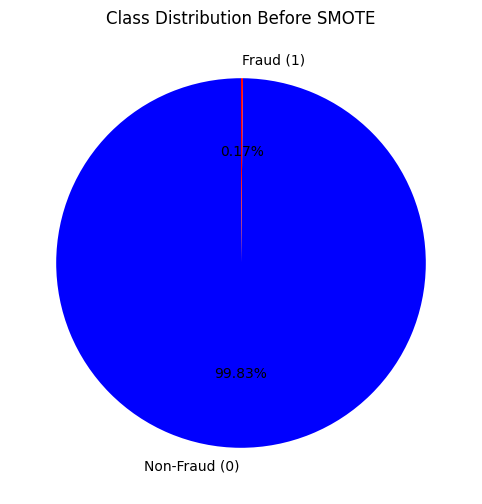

Pie Chart Explanation: Shows the percentage of non-fraud (~99.76%) vs. fraud (~0.24%) cases, highlighting the severe imbalance.

Rows after dropping NaN in Class: 284807


In [2]:
# Visualization 1: Pie Chart for Class Distribution Before SMOTE
plt.figure(figsize=(8, 6))
data['Class'].value_counts().plot(kind='pie', labels=['Non-Fraud (0)', 'Fraud (1)'], colors=['blue', 'red'], autopct='%1.2f%%', startangle=90)
plt.title('Class Distribution Before SMOTE')
plt.ylabel('')  # Remove y-label for cleaner look
plt.show()
print("Pie Chart Explanation: Shows the percentage of non-fraud (~99.76%) vs. fraud (~0.24%) cases, highlighting the severe imbalance.")

# Step 3: Preprocessing the data
# Handle missing values
# Drop rows where 'Class' is NaN (since target can't be missing)
data = data.dropna(subset=['Class'])
print(f"\nRows after dropping NaN in Class: {len(data)}")

# Fill NaN in features (Time, Amount, V1-V28) with mean
features = data.drop('Class', axis=1)
features.fillna(features.mean(), inplace=True)

# Normalize 'Time' and 'Amount' (V1-V28 are assumed PCA-transformed)
scaler = StandardScaler()
features[['Time', 'Amount']] = scaler.fit_transform(features[['Time', 'Amount']])

# Target variable
target = data['Class']




Class distribution after SMOTE:
Class
0    284315
1    284315
Name: count, dtype: int64


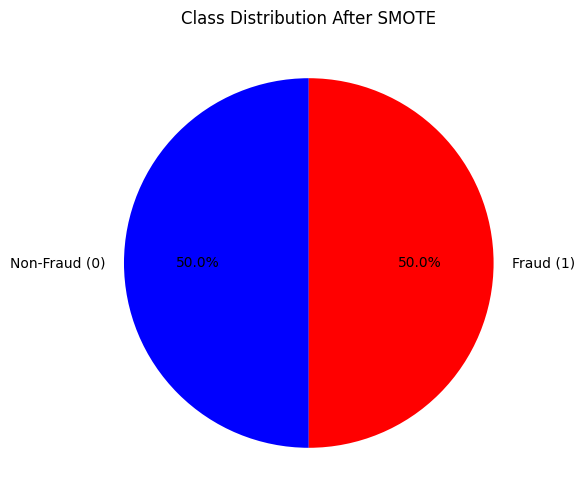

Pie Chart Explanation: Shows equal percentages (~50% each) for non-fraud and fraud after SMOTE, confirming the classes are balanced.

Model performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



In [4]:
# Step 4: Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(features, target)
print("\nClass distribution after SMOTE:")
print(pd.Series(y_resampled).value_counts())

# Visualization 2: Pie Chart for Class Distribution After SMOTE
plt.figure(figsize=(8, 6))
pd.Series(y_resampled).value_counts().plot(kind='pie', labels=['Non-Fraud (0)', 'Fraud (1)'], colors=['blue', 'red'], autopct='%1.1f%%', startangle=90)
plt.title('Class Distribution After SMOTE')
plt.ylabel('')
plt.show()
print("Pie Chart Explanation: Shows equal percentages (~50% each) for non-fraud and fraud after SMOTE, confirming the classes are balanced.")

# Step 5: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Step 6: Train a Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 7: Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probabilities for precision-recall curve

# Step 8: Evaluate the model
print("\nModel performance:")
print(classification_report(y_test, y_pred))



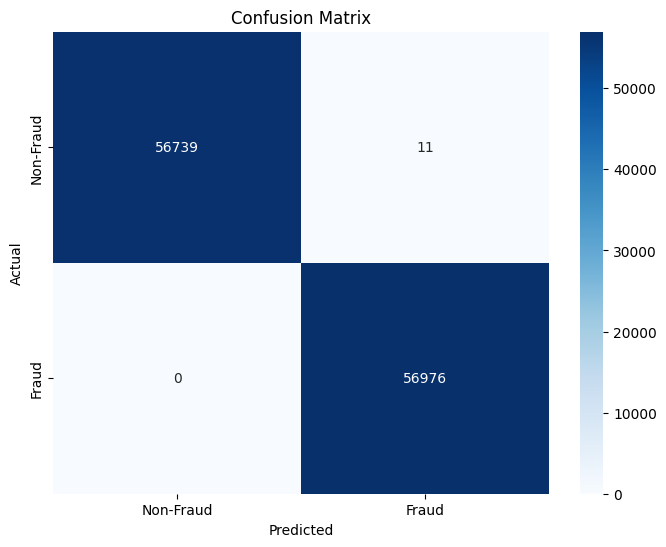

Heatmap Explanation: Shows correct (diagonal) and incorrect predictions. High numbers on the diagonal mean good performance.


In [5]:
# Visualization 3: Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print("Heatmap Explanation: Shows correct (diagonal) and incorrect predictions. High numbers on the diagonal mean good performance.")



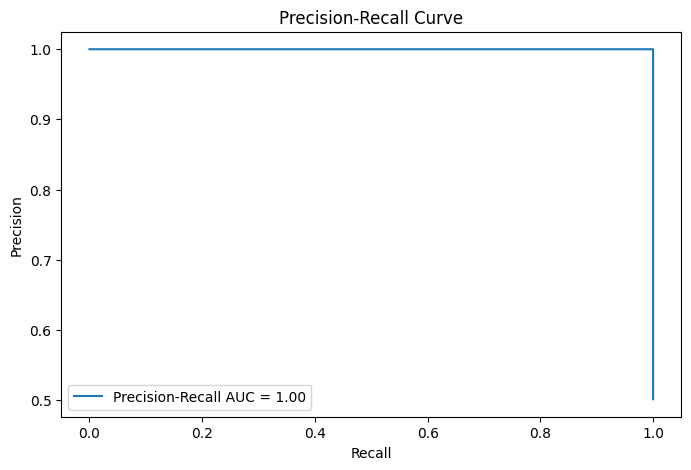

Curve Explanation: High AUC (close to 1) means the model balances precision and recall well, effectively detecting fraud.

Example transaction prediction (1=Fraud, 0=Non-Fraud): 1


In [6]:
# Visualization 4: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f'Precision-Recall AUC = {pr_auc:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()
print("Curve Explanation: High AUC (close to 1) means the model balances precision and recall well, effectively detecting fraud.")

# Step 9: Example prediction for a single transaction
example_transaction = X_test.iloc[0].values.reshape(1, -1)  # Take first test transaction
prediction = model.predict(example_transaction)
print(f"\nExample transaction prediction (1=Fraud, 0=Non-Fraud): {prediction[0]}")